# Text Generation using RNN, LSTM, and GRU

## Objective

The objective of this project is to understand how recurrent neural networks learn sequential text data and generate meaningful sentences. Three different recurrent architectures SimpleRNN, LSTM, and GRU are implemented and compared based on their training performance and generated text quality.

## Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**



In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Text Corpus

Instead of using the default sample text, a custom paragraph related to Artificial Intelligence and Deep Learning is used as the training corpus. This allows the models to learn domain specific vocabulary and sentence patterns while satisfying the assignment customization requirement.

In [31]:
corpus = """
Artificial intelligence is transforming industries by enabling machines to learn from data and make intelligent decisions.
Deep learning is a powerful branch of artificial intelligence that uses neural networks with multiple layers.
Recurrent neural networks are designed for sequential data and are widely used in natural language processing.
Long Short-Term Memory networks solve the vanishing gradient problem and capture long-term dependencies.
Gated Recurrent Units provide similar performance while requiring fewer computational resources.
Text generation models learn grammar, sentence structure, and contextual relationships to produce meaningful text.
Machine learning and deep learning continue to revolutionize healthcare, education, finance, transportation, and scientific research.
"""
corpus = corpus.lower()

## Text Preprocessing

The text is first converted to lowercase to maintain consistency during training. A tokenizer is then used to assign a unique integer index to every word in the corpus. These numerical representations are required because neural networks can only process numerical data.

Next, progressive n-gram sequences are created and padded so that all input sequences have the same length before being fed into the models.

In [32]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y[:5])

Vocabulary size: 81
X shape: (96, 15)
y shape: (96,)
[ 6  7 17 18 19]


## SimpleRNN Model

The first model uses a Simple Recurrent Neural Network. It consists of an embedding layer followed by a SimpleRNN layer and a dense output layer with softmax activation. This model serves as the baseline for comparing more advanced recurrent architectures.

In [24]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0104 - loss: 4.4081  
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1250 - loss: 4.2962
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2292 - loss: 4.2031
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2083 - loss: 4.0964
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1771 - loss: 3.9895
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1771 - loss: 3.8644
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1979 - loss: 3.7400
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2083 - loss: 3.6138
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3021 - loss: 3.4658
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3438 - loss: 3.3377
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3958 - loss: 3.1946
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4167 - 

## LSTM Model

The second model uses Long Short-Term Memory (LSTM) units. LSTMs are designed to capture long-term dependencies in sequential data and reduce the vanishing gradient problem commonly faced by traditional RNNs.

In [25]:
lstm_model = Sequential([
    Embedding(total_words,64,input_length=max_len-1),
    LSTM(128),
    Dense(total_words,activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.0312 - loss: 4.3957
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0938 - loss: 4.3861
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0833 - loss: 4.3752
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0833 - loss: 4.3627
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0833 - loss: 4.3409
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0729 - loss: 4.2951
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0729 - loss: 4.2274
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0729 - loss: 4.1991
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0521 - loss: 4.1606
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0833 - loss: 4.1055
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0729 - loss: 4.0499
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0938 - lo

## GRU Model

The third model uses Gated Recurrent Units (GRU). GRUs are similar to LSTMs but have a simpler architecture with fewer parameters, making them computationally efficient while still learning long-term contextual information.

In [26]:
gru_model = Sequential([
    Embedding(total_words,64,input_length=max_len-1),
    GRU(128),
    Dense(total_words,activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.0000e+00 - loss: 4.3955
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0625 - loss: 4.3823
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0729 - loss: 4.3707
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0729 - loss: 4.3590
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0625 - loss: 4.3437    
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0625 - loss: 4.3269
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0625 - loss: 4.3040
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0625 - loss: 4.2667
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0625 - loss: 4.2070
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0625 - loss: 4.1554    
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0625 - loss: 4.1405    
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accur

## Model Training

All three models are trained using the Adam optimizer with sparse categorical cross entropy as the loss function. The same training configuration is used for each model to ensure a fair comparison of their learning behavior.

## Training Loss Comparison

The loss curves of all three models are plotted to observe how quickly each architecture converges during training. Comparing these curves helps in understanding which model learns the text patterns more efficiently.

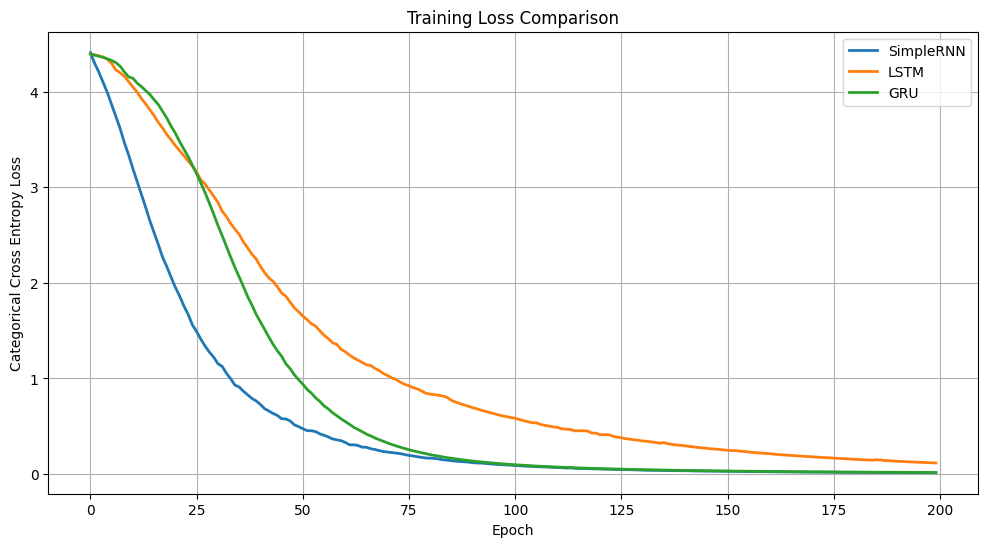

In [27]:
plt.figure(figsize=(12,6))

plt.plot(rnn_history.history['loss'],label='SimpleRNN',linewidth=2)

plt.plot(lstm_history.history['loss'],label='LSTM',linewidth=2)

plt.plot(gru_history.history['loss'],label='GRU',linewidth=2)

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Categorical Cross Entropy Loss")

plt.grid(True)

plt.legend()

plt.show()

## Text Generation

After training, each model generates text using the same seed phrase. The next word is selected by choosing the token with the highest predicted probability (`np.argmax`). The process is repeated until the required number of words has been generated.

In [28]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [29]:
seed = "deep learning"

print("="*60)
print("Seed Text :", seed)
print("="*60)

print("\nSimpleRNN")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM")
print(generate_text(lstm_model, seed, 10))

print("\nGRU")
print(generate_text(gru_model, seed, 10))

Seed Text : deep learning

SimpleRNN
deep learning is a powerful branch of artificial intelligence that uses neural

LSTM
deep learning is a powerful branch of artificial intelligence that uses neural

GRU
deep learning is a powerful branch of artificial intelligence that uses neural


## Assignment Customization

The following modifications were made as part of the learning tasks:

- Replaced the default sample corpus with a custom paragraph related to Artificial Intelligence.
- Increased the embedding dimension to improve word representations.
- Extended the training from 100 to 200 epochs.
- Increased the hidden layer size from 64 to 128 units.
- Modified the text generation function to produce 10 words for each prompt.

## Results

All three models successfully learned patterns from the training corpus and generated meaningful text based on the provided seed phrase. The generated sentences demonstrate that recurrent neural networks are capable of learning contextual relationships between words, although the quality varies across different architectures.

## Conclusion

In this project, three recurrent neural network architectures were implemented for text generation and compared using the same training data. The SimpleRNN model learned basic sequence patterns but showed limitations in maintaining long-term context. Both LSTM and GRU produced more coherent text, with smoother convergence during training.
This experiment provided practical understanding of text preprocessing, sequence generation, embedding layers, recurrent neural networks, and next-word prediction using deep learning.

## Learning Outcome

Through this assignment, I gained hands-on experience in preparing text data for sequence modeling, implementing different recurrent neural network architectures, comparing their performance, and generating text using next-word prediction. I also understood how architectural differences between RNN, LSTM, and GRU affect learning and text generation quality.